# Stock Price Predictor using Machine Learning

Initial imports

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf       # yahoo finance API from which we will get our data
import matplotlib.pyplot as plt     # Visualization

import torch        # Deep learning library
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import StandardScaler        # scale and...
from sklearn.metrics import root_mean_squared_error     # ... evaluation

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open    Volume
Ticker             SPY         SPY         SPY         SPY       SPY
Date                                                                
2020-01-02  296.125275  296.143523  293.992323  294.912966  59151200
2020-01-03  293.882965  295.004144  292.688877  292.743566  77709700
2020-01-06  295.004150  295.086184  292.014340  292.132842  55653900
2020-01-07  294.174622  294.912950  293.727958  294.438942  40496400
2020-01-08  295.742523  296.954832  294.120020  294.366120  68296000
...                ...         ...         ...         ...       ...
2026-09-01  761.780029  764.669983  759.479980  762.010010  41126300
2026-09-02  765.159973  766.429993  761.729980  762.450012  29566200
2026-09-03  773.169983  774.030029  767.450012  767.900024  43531600
2026-09-04  770.190002  772.869995  769.000000  772.010010  34015600
2026-09-08  766.940002  769.700012  765.989990  769.070007  14760448

[1679 rows x 5 columns]


<Axes: xlabel='Date'>

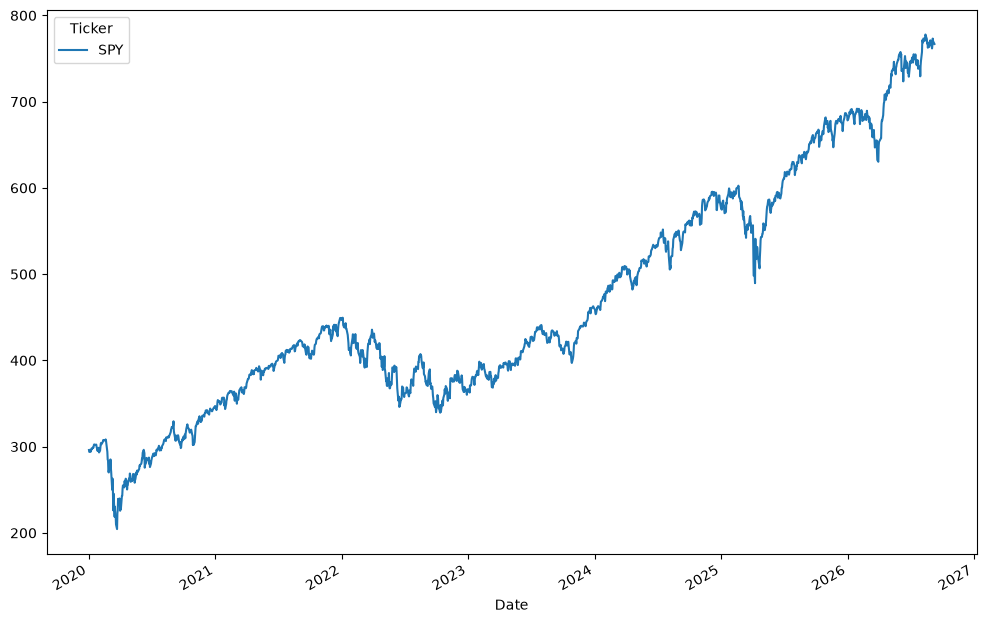

In [7]:
# Ideally, we want to use a CUDA supported GPU, but if unavailable, we can use any CPU
device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Next we want to take out ticker, in this case SPY, and load the ticker data into a dataframe from january of 2020
ticker = 'SPY'
df = yf.download(ticker, '2020-01-01')
print(df)
df.Close.plot(figsize=(12, 8))

We've taken our data from the yfinance import, loaded it into a dataframe and plotted the points. Our plan is to cut 80% of that data to train our model, and use it to predict or test it against the last 20% or so.